# 💳 CreditWise Loan Approval System

An intelligent Machine Learning system to automate and improve loan approval decisions using historical applicant data.

## 📌 Problem Statement

SecureTrust Bank currently relies on a **manual loan verification process**, where each application is evaluated based on documents such as income proof, employment details, and credit history.

This manual system has several limitations:

- ❌ Time-consuming and inefficient  
- ❌ Prone to human bias and inconsistency  
- ❌ Risk of rejecting eligible customers  
- ❌ Risk of approving high-risk applicants  

These challenges lead to:
- Loss of potential business opportunities  
- Increased financial risk due to loan defaults  

To overcome these issues, the bank aims to develop a **Machine Learning-based loan approval system** that can assist in making faster, more accurate, and unbiased decisions.

## 🎯 Objective

The main objective of this project is to build a **supervised Machine Learning model** that can predict whether a loan application should be:

- ✅ Approved (1)  
- ❌ Rejected (0)

### Key Goals:
- Analyze historical loan data to identify hidden patterns  
- Perform data preprocessing and feature engineering  
- Train multiple classification models (KNN, Logistic Regression, Naive Bayes)  
- Evaluate model performance using metrics like Precision, Recall, and F1-score  
- Select the best-performing model for deployment  

This system will act as a **decision-support tool** for banks to improve efficiency and reduce risk.

## 📊 Dataset Overview

The dataset consists of historical loan application records, where each row represents an individual applicant and their financial profile.

### 🔹 Features Description:

- **Applicant_ID**: Unique identifier for each applicant  
- **Applicant_Income**: Monthly income of the applicant  
- **Coapplicant_Income**: Monthly income of the co-applicant  
- **Employment_Status**: Employment type (Salaried, Self-Employed, Business)  
- **Age**: Age of the applicant  
- **Marital_Status**: Married or Single  
- **Dependents**: Number of dependents  
- **Credit_Score**: Creditworthiness score  
- **Existing_Loans**: Number of ongoing loans  
- **DTI_Ratio**: Debt-to-Income ratio  
- **Savings**: Applicant's savings balance  
- **Collateral_Value**: Value of collateral provided  
- **Loan_Amount**: Requested loan amount  
- **Loan_Term**: Loan duration (in months)  
- **Loan_Purpose**: Purpose (Home, Education, Personal, Business)  
- **Property_Area**: Urban, Semi-Urban, Rural  
- **Education_Level**: Graduate, Postgraduate, Undergraduate  
- **Gender**: Male or Female  
- **Employer_Category**: Government, Private, Self-employed  

### 🎯 Target Variable:
- **Loan_Approved**:
  - `1` → Approved  
  - `0` → Rejected  

This dataset will be used to train and evaluate classification models for loan approval prediction.

## 📥 Importing Libraries & Loading Data

In this section, we import all the necessary libraries required for data analysis, visualization, and machine learning.  
We also load the dataset and perform initial exploration to understand its structure and contents.

In [3]:
# Importing essential libraries for data manipulation
import pandas as pd
import numpy as np

# Libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Setting style for better visualization
sns.set(style="whitegrid")

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

### 📂 Loading the Dataset

We load the dataset into a Pandas DataFrame to begin analysis.

In [4]:
# Loading the dataset
df = pd.read_csv("loan_approval_data.csv")

# Display first 5 rows
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


### 🔍 Basic Dataset Information

Let's explore the dataset to understand:
- Number of rows and columns  
- Data types of each feature  
- Presence of missing values  

In [5]:
# Shape of dataset (rows, columns)
print("Dataset Shape:", df.shape)

# Information about dataset
df.info()

Dataset Shape: (1000, 20)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    str    
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    str    
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    str    
 15  Property_Area       950 non-null    str  

### 📊 Statistical Summary

We analyze numerical features to understand:
- Mean, median, and standard deviation  
- Minimum and maximum values  
- Distribution of numerical data  

In [6]:
# Summary statistics for numerical columns
df.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


### 🔤 Categorical Features Overview

We also explore categorical columns to understand unique values and distributions.

In [7]:
# Display unique values in categorical columns
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


Employment_Status:
Employment_Status
Salaried         465
Contract         213
Self-employed    182
Unemployed        90
Name: count, dtype: int64

Marital_Status:
Marital_Status
Married    593
Single     357
Name: count, dtype: int64

Loan_Purpose:
Loan_Purpose
Business     202
Car          199
Home         190
Education    181
Personal     178
Name: count, dtype: int64

Property_Area:
Property_Area
Urban        467
Rural        294
Semiurban    189
Name: count, dtype: int64

Education_Level:
Education_Level
Graduate        672
Not Graduate    278
Name: count, dtype: int64

Gender:
Gender
Male      571
Female    379
Name: count, dtype: int64

Employer_Category:
Employer_Category
Private       372
Government    202
MNC           144
Business      135
Unemployed     97
Name: count, dtype: int64

Loan_Approved:
Loan_Approved
No     652
Yes    298
Name: count, dtype: int64


In [8]:
# Check missing values
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

## 🧹 Data Cleaning & Preprocessing

In this section, we prepare the dataset for machine learning by handling missing values, encoding categorical variables, selecting relevant features, and scaling numerical data.

Proper preprocessing ensures better model performance and stability.

### 🔍 Handling Missing Values

Missing values can negatively impact model performance.  
We handle them using:

- **Mean Imputation** → for numerical features  
- **Most Frequent Imputation** → for categorical features  

In [9]:
# Separating categorical and numerical columns
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns

from sklearn.impute import SimpleImputer

# Imputing numerical columns with mean
num_imp = SimpleImputer(strategy="mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

# Imputing categorical columns with most frequent value
cat_imp = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

# Verifying missing values are handled
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

### 🔤 Encoding Categorical Variables

Machine learning models cannot understand categorical data directly.  
Therefore, we convert categorical features into numerical format using **Label Encoding**.

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encoding categorical columns
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,1,51.0,0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,4,2,1,0,3,0
1,2.0,2860.0,2679.0,1,46.0,0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,1,1,0,1,3,0
2,3.0,7390.0,2106.0,1,25.0,1,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,0,2,0,0,1,1
3,4.0,13964.0,8173.0,1,40.0,0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,0,0,0,0,1,0
4,5.0,13284.0,4223.0,2,31.0,1,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,1,2,0,1,3,1


### 🎯 Feature Selection

We separate the dataset into:

- **Features (X)** → Input variables  
- **Target (y)** → Loan approval status  

We drop unnecessary columns such as Applicant_ID as they do not contribute to prediction.

In [11]:
# Dropping unnecessary column
if "Applicant_ID" in df.columns:
    df = df.drop("Applicant_ID", axis=1)

# Splitting features and target
X = df.drop("Loan_Approved", axis=1)
y = df["Loan_Approved"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (1000, 18)
Target Shape: (1000,)


### ⚖️ Feature Scaling

Feature scaling ensures that all numerical features are on the same scale.  
This is especially important for models like KNN and Logistic Regression.

We use **StandardScaler** to normalize the data.

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scaling features
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 1.4079514 , -1.28890468, -0.17405794,  1.01625559, -0.74512412,
        -1.3699122 , -0.56161244,  1.49605597,  1.29957721,  1.65738245,
         1.4908814 , -0.34833973,  1.52419821,  1.49404857,  0.89053579,
         1.61155897, -1.28004782,  0.6917493 ],
       [-1.6209245 , -0.83827966, -0.17405794,  0.55551167, -0.74512412,
         1.41684709, -0.79181871,  0.03611435, -0.33612337, -1.28919672,
         1.75091543,  1.62079583,  0.        , -0.58390494, -0.25558492,
        -0.62051716,  0.78122081,  0.6917493 ],
       [-0.70222294, -1.03813116, -0.17405794, -1.3796128 ,  1.34205829,
         0.48792733, -0.02926043,  1.49605597, -1.04729753,  0.68371345,
        -1.28047746,  0.66210485,  1.01613214, -1.27655611,  0.89053579,
        -0.62051716, -1.28004782, -0.92448738],
       [ 0.63100975,  1.07792303, -0.17405794,  0.00261897, -0.74512412,
         0.48792733, -1.39611018,  0.76608516, -0.26500595, -0.06786304,
        -0.99883356,  0.65104029,  0.50806607, -1.276

## 📊 Exploratory Data Analysis (EDA)

In this section, we explore the dataset using visualizations to understand patterns, trends, and relationships between features.

EDA helps in:
- Understanding data distribution  
- Detecting patterns and anomalies  
- Identifying important features for prediction  

### 📈 Distribution of Numerical Features

We analyze how numerical features are distributed to understand skewness, spread, and potential outliers.

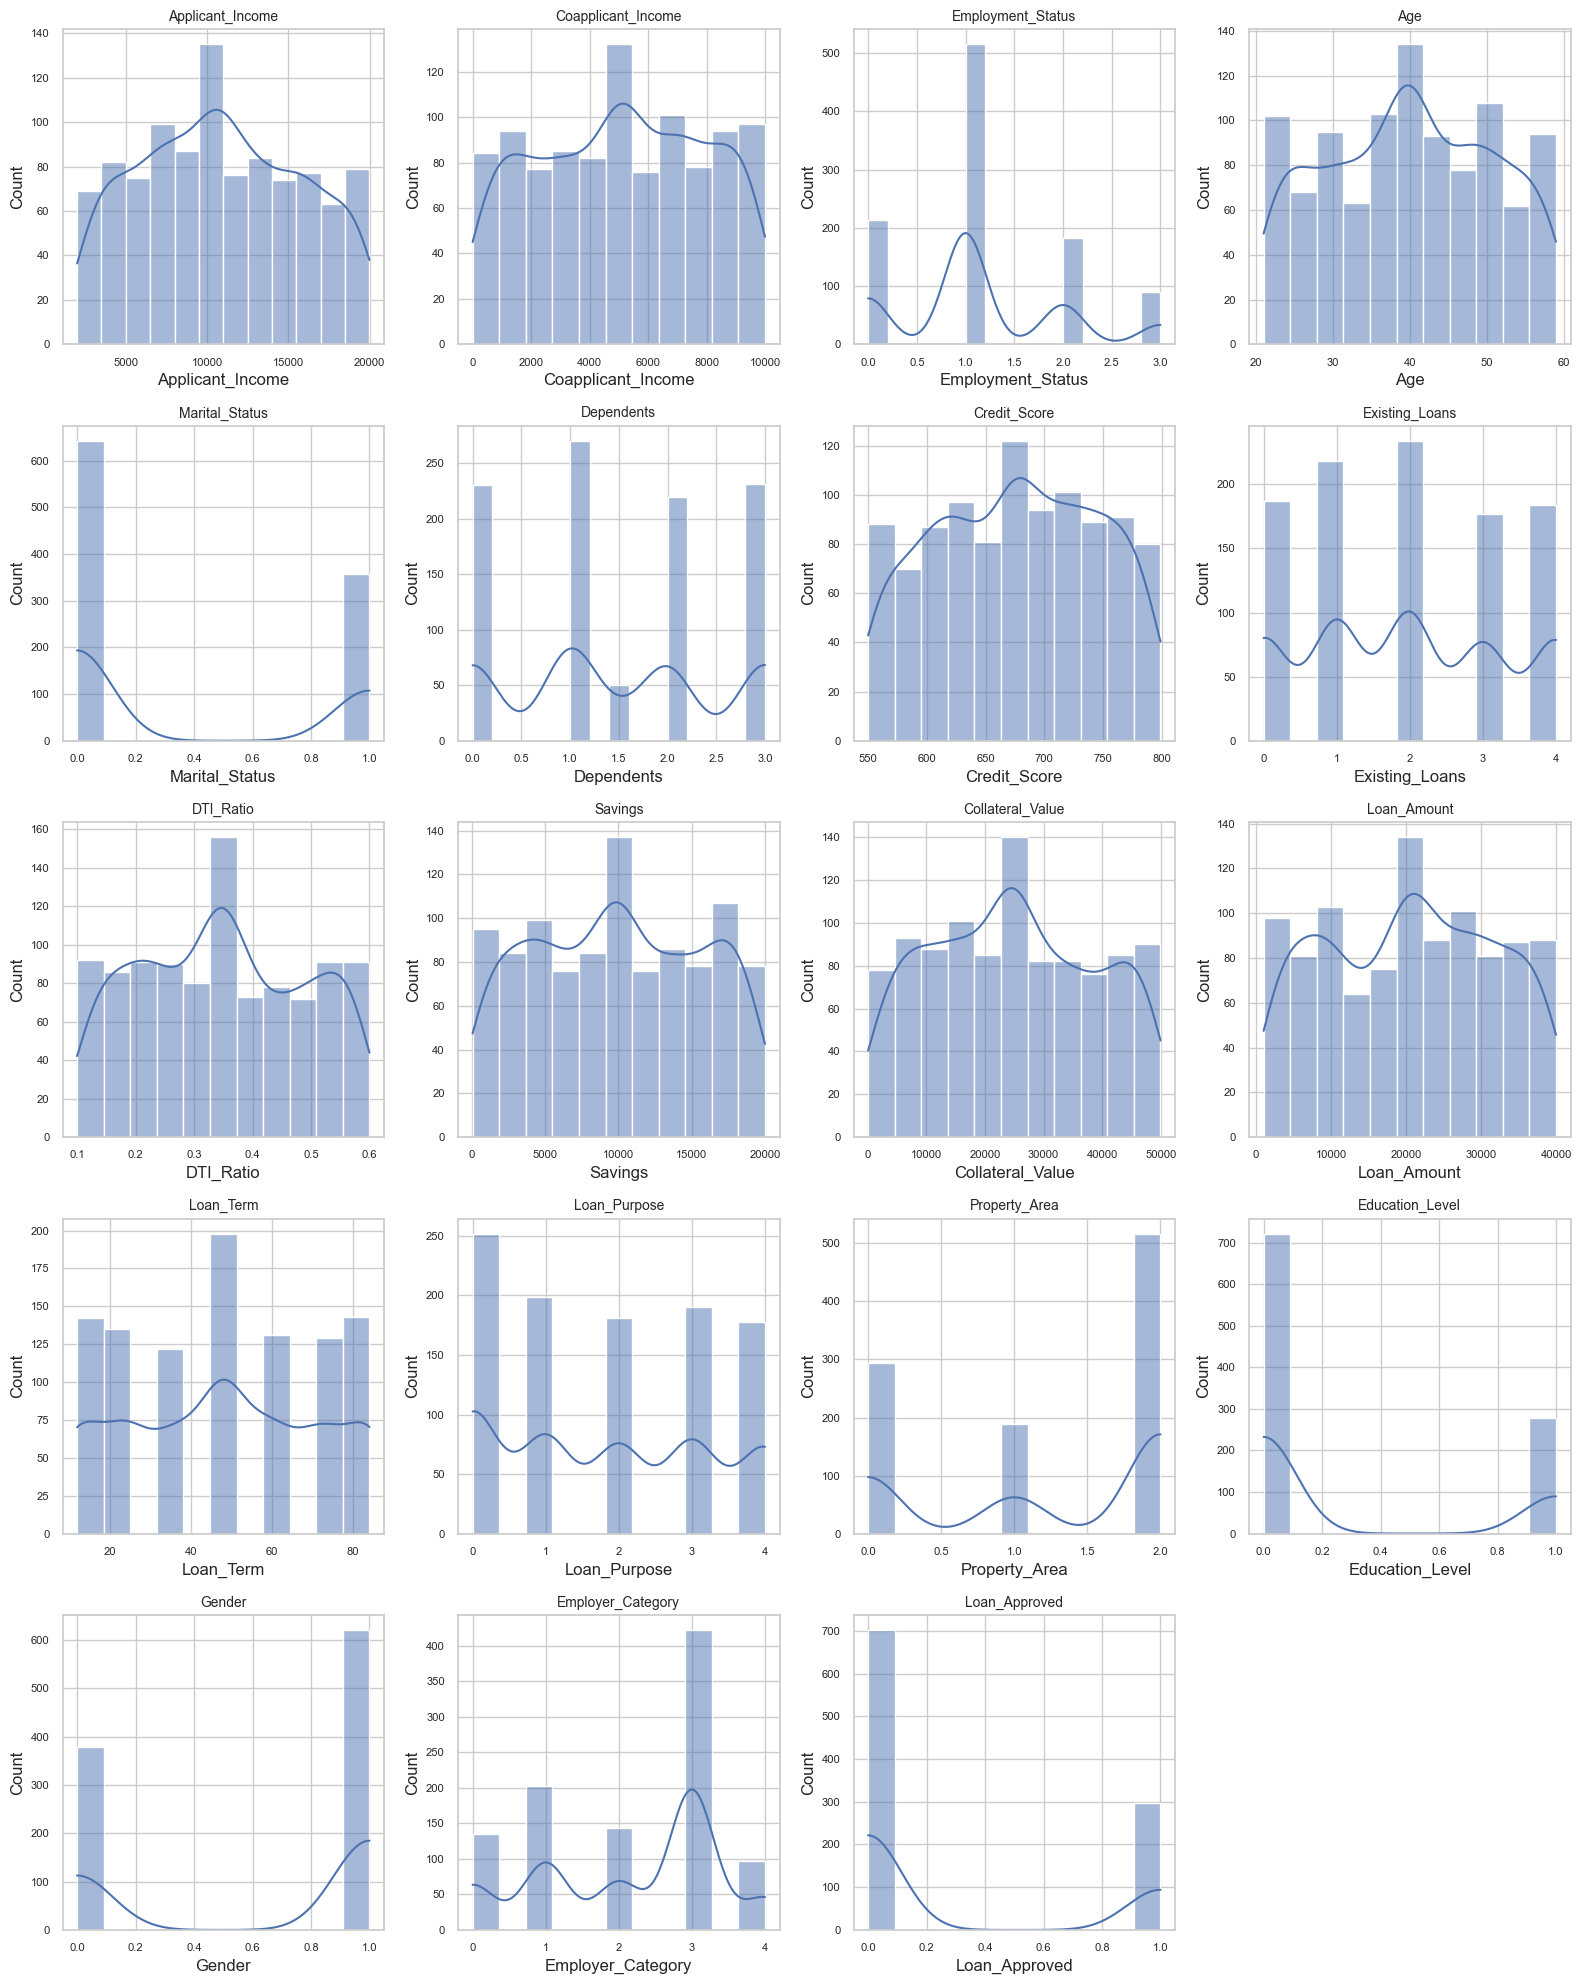

In [13]:
# Get numerical columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Define number of columns in grid
n_cols = 4
n_rows = (len(num_cols) + n_cols - 1) // n_cols  # dynamic rows

plt.figure(figsize=(16, n_rows * 4))

for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(col, fontsize=10)
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()

### 🎯 Loan Approval Distribution

Understanding the balance between approved and rejected loans.

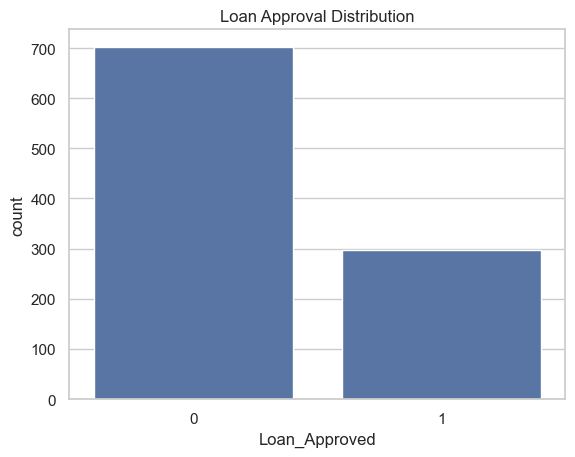

Loan_Approved
0    70.2
1    29.8
Name: proportion, dtype: float64

In [14]:
sns.countplot(x='Loan_Approved', data=df)
plt.title("Loan Approval Distribution")
plt.show()

# Percentage distribution
df['Loan_Approved'].value_counts(normalize=True) * 100

### 🔗 Correlation Analysis

Correlation helps us understand relationships between numerical features and their impact on loan approval.

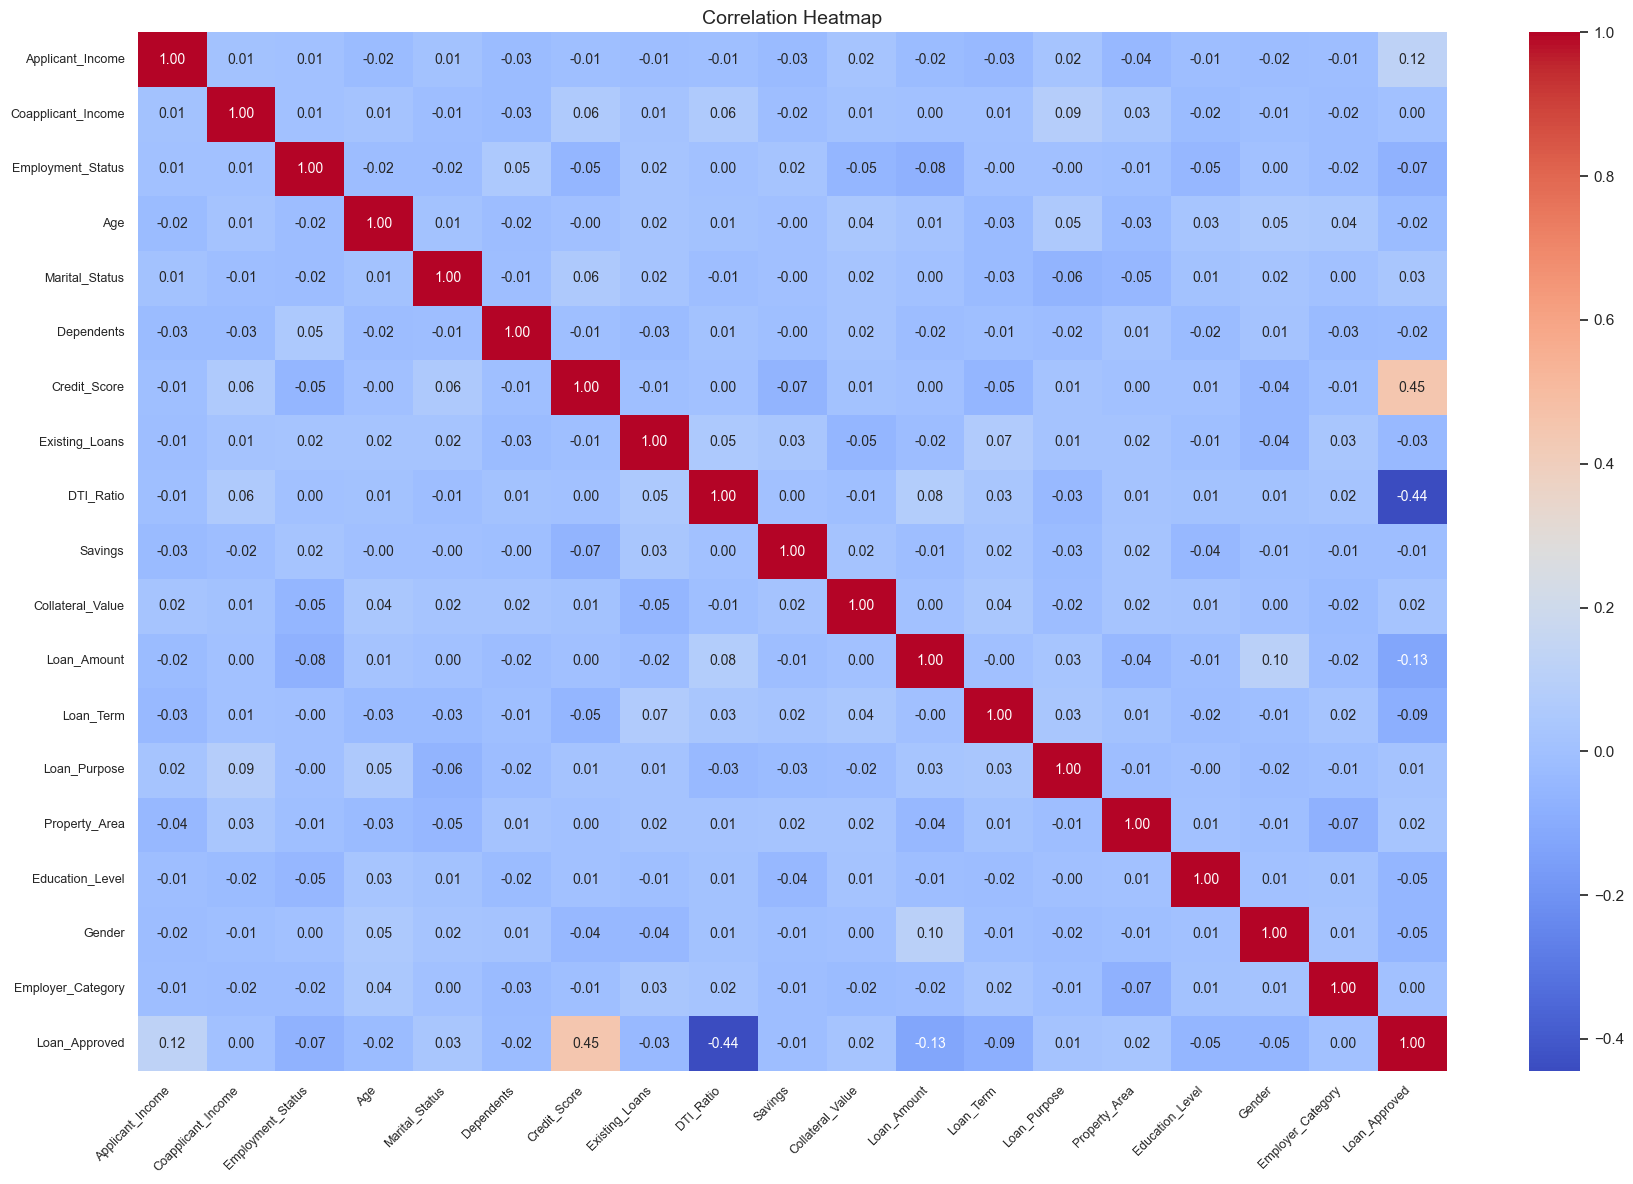

In [26]:
plt.figure(figsize=(18, 12))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 10}
)

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)

plt.title("Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

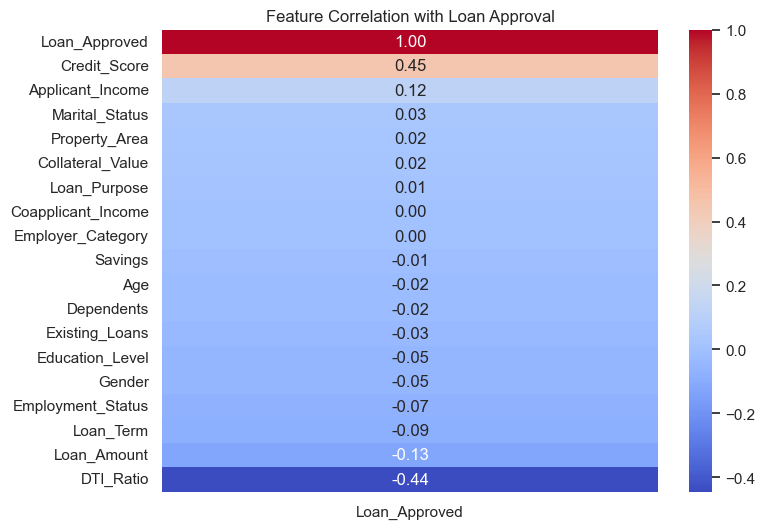

In [27]:
plt.figure(figsize=(8, 6))

corr_target = df.corr()["Loan_Approved"].sort_values(ascending=False)

sns.heatmap(
    corr_target.to_frame(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation with Loan Approval")
plt.show()

### 🔍 Feature Relationship with Loan Approval

We analyze how important features influence loan approval decisions.

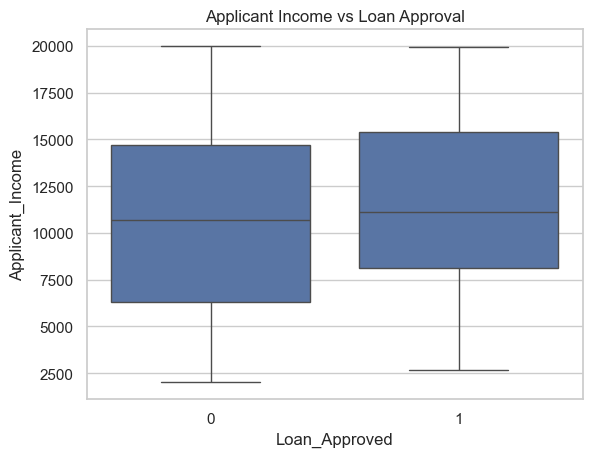

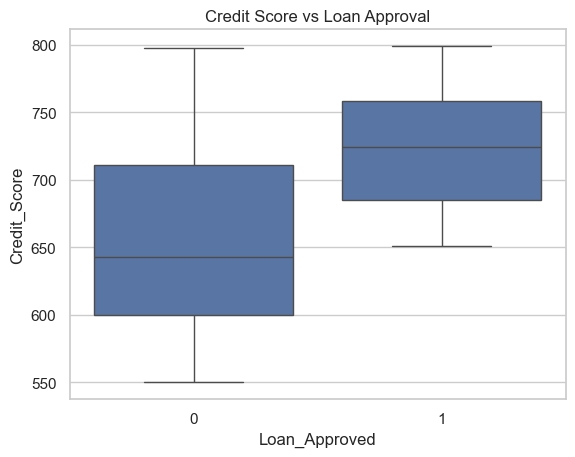

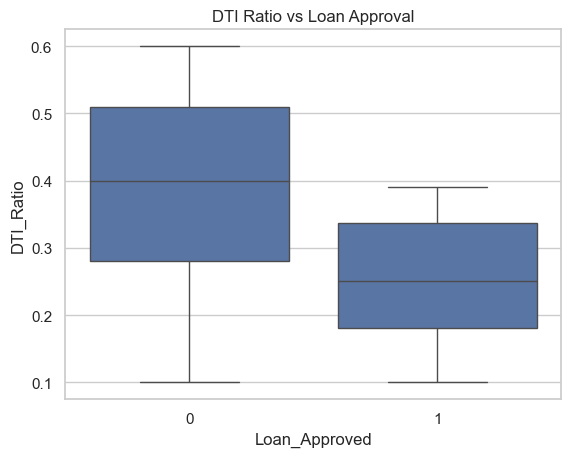

In [28]:
# Income vs Loan Approval
sns.boxplot(x='Loan_Approved', y='Applicant_Income', data=df)
plt.title("Applicant Income vs Loan Approval")
plt.show()

# Credit Score vs Loan Approval
sns.boxplot(x='Loan_Approved', y='Credit_Score', data=df)
plt.title("Credit Score vs Loan Approval")
plt.show()

# DTI Ratio vs Loan Approval
sns.boxplot(x='Loan_Approved', y='DTI_Ratio', data=df)
plt.title("DTI Ratio vs Loan Approval")
plt.show()

## 💡 Key Insights from EDA

Based on the analysis:

- Applicants with higher **credit scores** are more likely to get loan approval  
- Higher **applicant income** increases approval chances  
- Lower **DTI ratio** (debt burden) improves approval probability  
- Certain features show moderate correlation with the target variable  
- Dataset appears reasonably balanced (if applicable)

These insights help guide model selection and feature importance in later stages.

## 🤖 Model Building

In this section, we train multiple machine learning models to predict loan approval.

We use the following algorithms:
- K-Nearest Neighbors (KNN)
- Logistic Regression
- Naive Bayes

These models are chosen to compare different approaches to classification.

### 🔀 Train-Test Split

We split the dataset into training and testing sets to evaluate model performance on unseen data.

In [29]:
from sklearn.model_selection import train_test_split

# Using scaled data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (800, 18)
Testing set: (200, 18)


### 📍 K-Nearest Neighbors (KNN)

KNN is a distance-based algorithm that classifies data points based on their nearest neighbors.

In [30]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize model
knn = KNeighborsClassifier(n_neighbors=5)

# Train model
knn.fit(X_train, y_train)

# Predictions
y_pred_knn = knn.predict(X_test)

### 📍 Logistic Regression

Logistic Regression is a linear model used for binary classification problems.

In [31]:
from sklearn.linear_model import LogisticRegression

# Initialize model
lr = LogisticRegression()

# Train model
lr.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_test)

### 📍 Naive Bayes

Naive Bayes is a probabilistic classifier based on Bayes' theorem, assuming feature independence.

In [32]:
from sklearn.naive_bayes import GaussianNB

# Initialize model
nb = GaussianNB()

# Train model
nb.fit(X_train, y_train)

# Predictions
y_pred_nb = nb.predict(X_test)

In [33]:
models_predictions = {
    "KNN": y_pred_knn,
    "Logistic Regression": y_pred_lr,
    "Naive Bayes": y_pred_nb
}

## 📊 Model Evaluation & Conclusion

In this section, we evaluate the performance of all trained models using classification metrics and compare their effectiveness in predicting loan approval.

### 📏 Evaluation Metrics

We use the following metrics:

- **Accuracy** → Overall correctness of the model  
- **Precision** → How many predicted approvals were actually correct  
- **Recall** → How many actual approvals were correctly identified  
- **F1 Score** → Balance between Precision and Recall  

These metrics help us understand model performance beyond just accuracy.

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

### 📌 Model Performance Evaluation

In [35]:
def evaluate_model(y_test, y_pred, model_name):
    print(f"🔹 {model_name} Performance:")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print("-" * 40)

In [36]:
evaluate_model(y_test, y_pred_knn, "KNN")
evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_nb, "Naive Bayes")

🔹 KNN Performance:
Accuracy : 0.79
Precision: 0.6461538461538462
Recall   : 0.6885245901639344
F1 Score : 0.6666666666666666
----------------------------------------
🔹 Logistic Regression Performance:
Accuracy : 0.855
Precision: 0.7666666666666667
Recall   : 0.7540983606557377
F1 Score : 0.7603305785123967
----------------------------------------
🔹 Naive Bayes Performance:
Accuracy : 0.875
Precision: 0.8214285714285714
Recall   : 0.7540983606557377
F1 Score : 0.7863247863247863
----------------------------------------


### 📊 Model Comparison

In [39]:
import pandas as pd

results = []

models = {
    "KNN": y_pred_knn,
    "Logistic Regression": y_pred_lr,
    "Naive Bayes": y_pred_nb
}

for name, y_pred in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,0.790,0.646154,0.688525,0.666667
1,Logistic Regression,0.855,0.766667,0.754098,0.760331
2,Naive Bayes,0.875,0.821429,0.754098,0.786325


### 🏆 Best Model Selection

Based on the evaluation metrics, we select the model with the best balance of performance.

Typically, the model with the highest **F1 Score** is preferred, as it balances both Precision and Recall.

## ✅ Final Conclusion

In this project, we developed a machine learning system to predict loan approval decisions based on applicant data.

### 🔍 Key Highlights:
- Performed data cleaning and preprocessing to handle missing values and categorical variables  
- Conducted exploratory data analysis to identify important features  
- Trained multiple classification models including KNN, Logistic Regression, and Naive Bayes  
- Evaluated models using Accuracy, Precision, Recall, and F1 Score  

### 🏆 Final Outcome:
- The best-performing model was **Naive Bayes** based on evaluation metrics  
- Key factors influencing loan approval include **Credit Score, Applicant Income, and DTI Ratio**

### 🚀 Future Improvements:
- Use advanced models like Random Forest or XGBoost  
- Perform hyperparameter tuning  
- Deploy the model using Streamlit for real-time predictions  

This project demonstrates how machine learning can assist financial institutions in making faster and more reliable loan approval decisions.